In [1]:
import timesfm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm 
import os 
from itertools import product
from collections import defaultdict
import time

from timesfm_functions import (
    TimesFMModel,
    load_aluminium_data,
    calculate_prediction_metrics
)

from functions import line_plot, mape, mae, rmse, mse, mase, pred_value_to_char

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


/home/panstenos/.pyenv/versions/3.11.10/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded PyTorch TimesFM, likely because python version is 3.11.10 (main, Aug 20 2025, 22:27:03) [GCC 13.3.0].


In [2]:
df = load_aluminium_data()
df.head(15)

,al_lme_prices_log_returns,al_lme_prices_daily_returns,us_dollar_index,canadian_dollar_spot,emirate_dirham_spot,russian_ruble_spot,nor_krone_spot,australian_dollar_spot,malaysian_ringgit_spot,euro_spot,...,us_gdp_agr,china_caixin_pmi,germany_pmi,japan_pmi,us_pmi,1w_vol,1m_vol,3m_vol,1y_vol,al_lme_prices_abs_log_returns
date,,,,,,,,,,,,,,,,,,,,,
1/18/2016,0.009106,0.009148,98.956,1.4561,3.6726,79.3775,8.8984,1.457089,4.3930,0.918274,...,2.0,48.2,53.2,52.6,51.2,NaN,NaN,NaN,NaN,0.009106
1/19/2016,-0.004711,-0.004700,98.991,1.4576,3.6723,78.7850,8.8061,1.448646,4.3625,0.917011,...,2.0,48.2,53.2,52.6,51.2,NaN,NaN,NaN,NaN,0.004711
1/20/2016,-0.012730,-0.012650,99.091,1.4501,3.6723,81.3475,8.8728,1.448016,4.3910,0.918358,...,2.0,48.2,53.2,52.6,51.2,NaN,NaN,NaN,NaN,0.012730
1/21/2016,0.015257,0.015374,99.056,1.4261,3.6722,82.3675,8.7823,1.429388,4.3730,0.919794,...,2.0,48.2,53.2,52.6,51.2,NaN,NaN,NaN,NaN,0.015257
1/22/2016,-0.002189,-0.002187,99.574,1.4115,3.6722,78.1000,8.7341,1.428571,4.2940,0.926441,...,2.0,48.2,53.2,52.6,51.2,0.177532,NaN,NaN,NaN,0.002189
1/25/2016,-0.005071,-0.005058,99.360,1.4289,3.6727,79.9404,8.7518,1.438021,4.2940,0.921914,...,2.0,48.2,53.2,52.6,51.2,0.164534,NaN,NaN,NaN,0.005071
1/26/2016,0.012630,0.012710,99.360,1.4114,3.6726,78.8250,8.6940,1.428163,4.2885,0.920048,...,2.0,48.2,53.2,52.6,51.2,0.189896,NaN,NaN,NaN,0.012630
1/27/2016,0.022175,0.022423,98.902,1.4091,3.6723,78.0450,8.6598,1.423488,4.2530,0.918189,...,2.0,48.2,53.2,52.6,51.2,0.185831,NaN,NaN,NaN,0.022175
1/28/2016,-0.007887,-0.007856,98.510,1.4027,3.6720,76.3280,8.6109,1.411632,4.2100,0.914328,...,2.0,48.2,53.2,52.6,51.2,0.204941,NaN,NaN,NaN,0.007887


In [3]:
batch_size = 64
context_len = 10
horizon_len = 5

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df["y"] = scaler.fit_transform(df[["al_lme_prices_abs_log_returns"]]).ravel()

In [5]:
# Data pipelining
def get_batched_data_fn(batch_size, context_len, horizon_len):
  examples = defaultdict(list)
  sub_df = df.iloc[horizon_len-1:, :]
  num_examples = 0
  for start in range(0, len(sub_df) - (context_len + horizon_len), 1):
    num_examples += 1
    examples["y"].append(sub_df['y'][start+context_len-1])
    examples['inputs'].append(sub_df['1w_vol'][start:start + context_len])
  def data_fn():
    for i in range(1 + (num_examples - 1) // batch_size):
      yield {k: v[(i * batch_size) : ((i + 1) * batch_size)] for k, v in examples.items()}
  
  return data_fn

In [6]:
timesfm_backend = "gpu"
model = TimesFMModel(expiry=horizon_len, context_length=context_len, positional_embedding=False)

[TimesFM] context_length 10 -> aligned to 32 (multiple of 32).


Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 19030.42it/s]


In [7]:
input_data = get_batched_data_fn(batch_size = batch_size, context_len=context_len, horizon_len=horizon_len)
metrics = defaultdict(list)

def _last_step(x):
    arr = np.asarray(x)
    if arr.ndim != 2:
        raise ValueError(f"Forecast must be 2D (batch, horizon), got {arr.shape}")
    return arr[:, -1].astype(float).tolist()

all_forecasts = []
all_cov_forecasts = []
for i, example in enumerate(input_data()):
    raw_forecast, _ = model.predict(
        inputs=example["inputs"], freq=[0] * len(example["inputs"])
    )
    start_time = time.time()
    cov_forecast, ols_forecast = model.predict_with_covariates(
        inputs=example["inputs"],
        dynamic_numerical_covariates={},
        dynamic_categorical_covariates={},
        static_numerical_covariates={
            "y": example['y'],
        },
        static_categorical_covariates={},
        freq=[0] * len(example["inputs"]),
        xreg_mode="xreg + timesfm",
        ridge=0.0,
        force_on_cpu=False,
        normalize_xreg_target_per_input=True,
    )
    all_forecasts.extend(_last_step(raw_forecast))
    all_cov_forecasts.extend(_last_step(cov_forecast))

/tmp/ipykernel_1487317/1592930219.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  examples["y"].append(sub_df['y'][start+context_len-1])


In [8]:
y = df['1w_vol'][-250:].tolist()

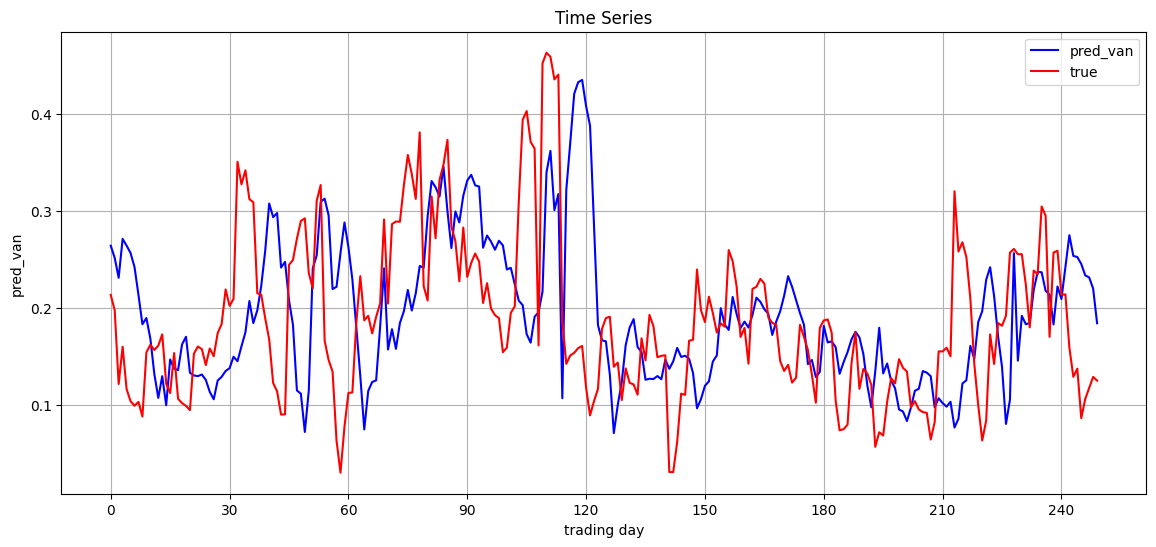

In [9]:
ax, fig = line_plot(all_forecasts[-250:], all_forecasts[-250:], 'pred_van', show=False)
_, _ = line_plot(y, y, 'true', ax=ax, linecolor='red', show=True)

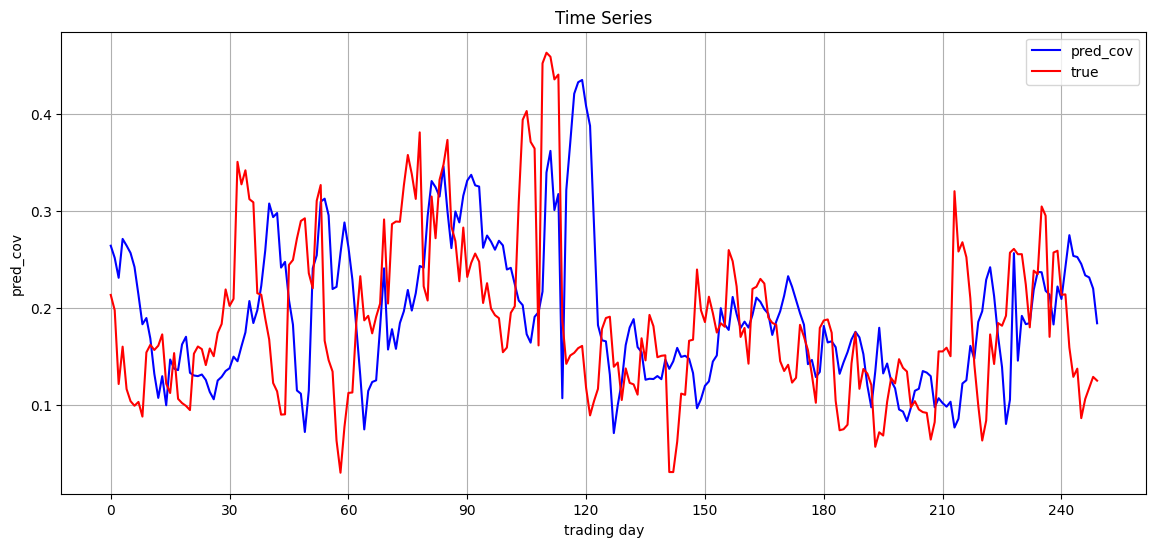

In [10]:
ax, fig = line_plot(all_cov_forecasts[-250:], all_cov_forecasts[-250:], 'pred_cov', show=False)
_, _ = line_plot(y, y, 'true', ax=ax, linecolor='red', show=True)

In [20]:
# Data pipelining
def get_batched_data_fn(batch_size, context_len, horizon_len):
  examples = defaultdict(list)
  num_examples = 0
  for start in range(0, len(df) - (context_len + horizon_len), 1):
    num_examples += 1
    examples['inputs'].append(df['al_lme_prices_log_returns'][start:start + context_len])
  def data_fn():
    for i in range(1 + (num_examples - 1) // batch_size):
      yield {k: v[(i * batch_size) : ((i + 1) * batch_size)] for k, v in examples.items()}
  
  return data_fn

In [21]:
timesfm_backend = "gpu"
model = TimesFMModel(expiry=horizon_len, context_length=context_len, positional_embedding=False)

[TimesFM] context_length 10 -> aligned to 32 (multiple of 32).


Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 23590.01it/s]


In [22]:
input_data = get_batched_data_fn(batch_size = batch_size, context_len=context_len, horizon_len=horizon_len)
metrics = defaultdict(list)

def _last_step(x):
    arr = np.asarray(x)
    if arr.ndim != 2:
        raise ValueError(f"Forecast must be 2D (batch, horizon), got {arr.shape}")
    return arr[:, -1].astype(float).tolist()

all_forecasts = []
all_cov_forecasts = []
for i, example in enumerate(input_data()):
    raw_forecast, _ = model.predict(
        inputs=example["inputs"], freq=[0] * len(example["inputs"])
    )
    # start_time = time.time()
    # cov_forecast, ols_forecast = model.predict_with_covariates(
    #     inputs=example["inputs"],
    #     dynamic_numerical_covariates={},
    #     dynamic_categorical_covariates={},
    #     static_numerical_covariates={
    #         "y": example['y'],
    #     },
    #     static_categorical_covariates={},
    #     freq=[0] * len(example["inputs"]),
    #     xreg_mode="xreg + timesfm",
    #     ridge=0.0,
    #     force_on_cpu=False,
    #     normalize_xreg_target_per_input=True,
    # )
    all_forecasts.extend(_last_step(raw_forecast))
    # all_cov_forecasts.extend(_last_step(cov_forecast))

In [23]:
y = df['al_lme_prices_log_returns'][-250:].tolist()

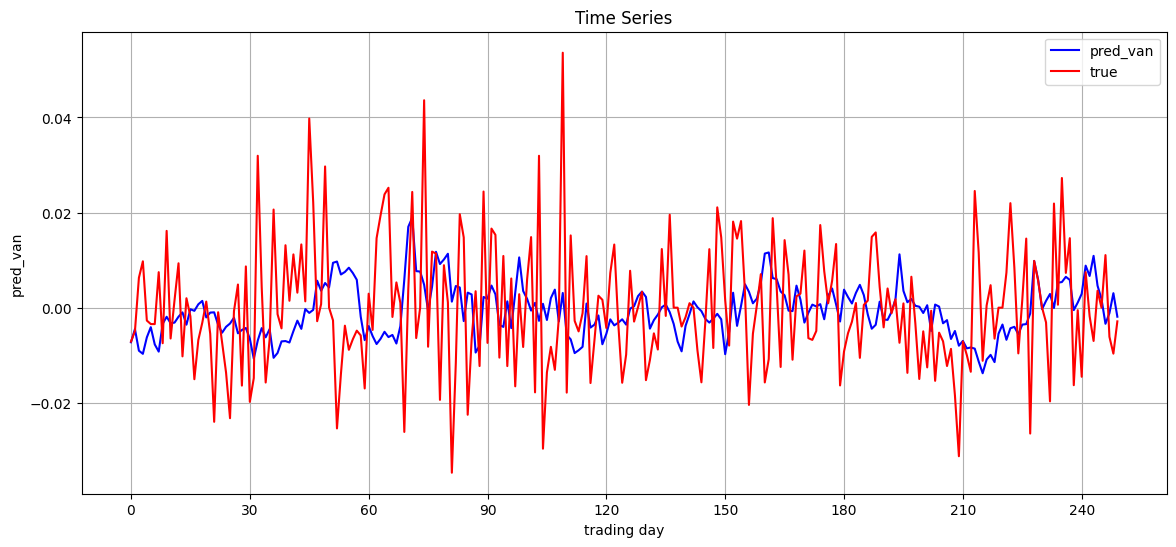

In [24]:
ax, fig = line_plot(all_forecasts[-250:], all_forecasts[-250:], 'pred_van', show=False)
_, _ = line_plot(y, y, 'true', ax=ax, linecolor='red', show=True)